In [136]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download('artempozdniakov/ukrainian-market-mobile-phones-data')

print('Path to dataset files:', path)

csv_name = os.listdir(path)
csv_name = " ".join(csv_name) # Convert list to string

csv_path = os.path.join(path, csv_name)

raw_df = pd.read_csv(csv_path)

raw_df.head()

df = raw_df.copy()

Using Colab cache for faster access to the 'ukrainian-market-mobile-phones-data' dataset.
Path to dataset files: /kaggle/input/ukrainian-market-mobile-phones-data


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      1224 non-null   int64  
 1   brand_name      1224 non-null   object 
 2   model_name      1224 non-null   object 
 3   os              1027 non-null   object 
 4   popularity      1224 non-null   int64  
 5   best_price      1224 non-null   float64
 6   lowest_price    964 non-null    float64
 7   highest_price   964 non-null    float64
 8   sellers_amount  1224 non-null   int64  
 9   screen_size     1222 non-null   float64
 10  memory_size     1112 non-null   float64
 11  battery_size    1214 non-null   float64
 12  release_date    1224 non-null   object 
dtypes: float64(6), int64(3), object(4)
memory usage: 124.4+ KB


In [139]:
df.describe()

,Unnamed: 0,popularity,best_price,lowest_price,highest_price,sellers_amount,screen_size,memory_size,battery_size
count,1224.000000,1224.000000,1224.000000,964.000000,964.000000,1224.000000,1222.000000,1112.000000,1214.000000
mean,611.500000,612.500000,7941.206699,7716.018672,9883.410788,16.743464,5.394378,95.700059,3608.201812
std,353.482673,353.482673,8891.836260,8560.959059,11514.936818,20.597006,1.476991,111.922576,1668.268774
min,0.000000,1.000000,214.000000,198.000000,229.000000,1.000000,1.400000,0.003200,460.000000
25%,305.750000,306.750000,2599.750000,2399.000000,2887.000000,2.000000,5.162500,32.000000,2900.000000
50%,611.500000,612.500000,4728.000000,4574.000000,5325.500000,8.000000,6.000000,64.000000,3687.000000
75%,917.250000,918.250000,9323.000000,9262.250000,12673.750000,26.000000,6.400000,128.000000,4400.000000
max,1223.000000,1224.000000,56082.000000,49999.000000,69999.000000,125.000000,8.100000,1000.000000,18800.000000


In [140]:
df.head()

,Unnamed: 0,brand_name,model_name,os,popularity,best_price,lowest_price,highest_price,sellers_amount,screen_size,memory_size,battery_size,release_date
0,0,ALCATEL,1 1/8GB Bluish Black (5033D-2JALUAA),Android,422,1690.0,1529.0,1819.0,36,5.00,8.0,2000.0,10-2020
1,1,ALCATEL,1 5033D 1/16GB Volcano Black (5033D-2LALUAF),Android,323,1803.0,1659.0,2489.0,36,5.00,16.0,2000.0,9-2020
2,2,ALCATEL,1 5033D 1/16GB Volcano Black (5033D-2LALUAF),Android,299,1803.0,1659.0,2489.0,36,5.00,16.0,2000.0,9-2020
3,3,ALCATEL,1 5033D 1/16GB Volcano Black (5033D-2LALUAF),Android,287,1803.0,1659.0,2489.0,36,5.00,16.0,2000.0,9-2020
4,4,Nokia,1.3 1/16GB Charcoal,Android,1047,1999.0,NaN,NaN,10,5.71,16.0,3000.0,4-2020


In [141]:
# df.columns

In [142]:
df.drop(['Unnamed: 0'], inplace=True, axis=1) # Unnamed: 0 column has index

In [143]:
# df.columns

In [144]:
# Best_price, lowest_price and highest_price are in UAH currency, changing them to EUR currency
import requests

def API_change_rate():
    url = 'https://open.er-api.com/v6/latest/UAH'

    response = requests.get(url)

    if response.status_code != 200:
        #print("Request failed")
        return None

    data = response.json()

    if data['result'] != 'success':
        #print("API error")
        return None

    eur_rate = data['rates']['EUR']

    return eur_rate

def currency_change(UAH):
  return UAH*rate

rate = round(API_change_rate(),3)
#print(rate)

# Manually having a value in rate, in case API request fails
if rate is None:
  rate = 0.019

df['best_price'] = df['best_price'].map(currency_change)
df['lowest_price'] = df['lowest_price'].map(currency_change)
df['highest_price'] = df['highest_price'].map(currency_change)

> Handling missing values of the dataset






In [145]:
# Handling Missing Values
df.isna().sum()

,0
brand_name,0
model_name,0
os,197
popularity,0
best_price,0
lowest_price,260
highest_price,260
sellers_amount,0
screen_size,2
memory_size,112


In [146]:
# OS
# We can't "guess" the phone's missing OS, so we replace NaN values with Unknown
df['os'].value_counts()
df['os'] = df['os'].fillna('Unknown')
df['os'].value_counts()

,count
os,
Android,915
Unknown,197
iOS,103
OxygenOS,3
WindowsPhone,3
EMUI,2
KAIOS,1


In [147]:
# Missing Price Values
# We will use the mean of each column respectively to fill the NaN values
df['lowest_price'] = df['lowest_price'].fillna(df['lowest_price'].mean)
df['highest_price'] = df['highest_price'].fillna(df['highest_price'].mean)

In [148]:
# Missing Battery Size Values
# Filling each NaN value with the brand's median battery size

na_index = df[df['battery_size'].isna()].index
na_index

for i in na_index:
  #print(df['brand_name'][i])
  copy_df = df.copy()
  brand_name = df['brand_name'][i]
  mask = df['brand_name'] == brand_name
  copy_df = df[mask]
  #df['battery_size'][i] = 1
  df.loc[i,'battery_size'] = copy_df['battery_size'].median()

# Filling potential NaN values (Brand Name appearing only once)
# with the column's median
df['battery_size'] = df['battery_size'].fillna(df['battery_size'].median())

In [149]:
# Missing Screen Size Values
# Similar with battery size, filling each NaN value with
# the brand's median screen size

na_index = df[df['screen_size'].isna()].index
na_index

for i in na_index:
  #print(df['brand_name'][i])
  copy_df = df.copy()
  brand_name = df['brand_name'][i]
  mask = df['brand_name'] == brand_name
  copy_df = df[mask]
  #df['battery_size'][i] = 1
  df.loc[i,'screen_size'] = copy_df['screen_size'].median()

# Filling potential NaN values (Brand Name appearing only once)
# with the column's median
df['screen_size'] = df['screen_size'].fillna(df['screen_size'].median())

In [150]:
# Missing Memory Size Values
# Similar with battery size, filling each NaN value with
# the brand's median memory size

na_index = df[df['memory_size'].isna()].index
na_index

for i in na_index:
  #print(df['brand_name'][i])
  copy_df = df.copy()
  brand_name = df['brand_name'][i]
  mask = df['brand_name'] == brand_name
  copy_df = df[mask]
  #df['battery_size'][i] = 1
  df.loc[i,'memory_size'] = copy_df['memory_size'].median()

# Filling potential NaN values (Brand Name appearing only once)
# with the column's media
df['memory_size'] = df['memory_size'].fillna(df['memory_size'].median())

In [151]:
# Handling Missing Values
df.isna().sum()

,0
brand_name,0
model_name,0
os,0
popularity,0
best_price,0
lowest_price,0
highest_price,0
sellers_amount,0
screen_size,0
memory_size,0


Plot



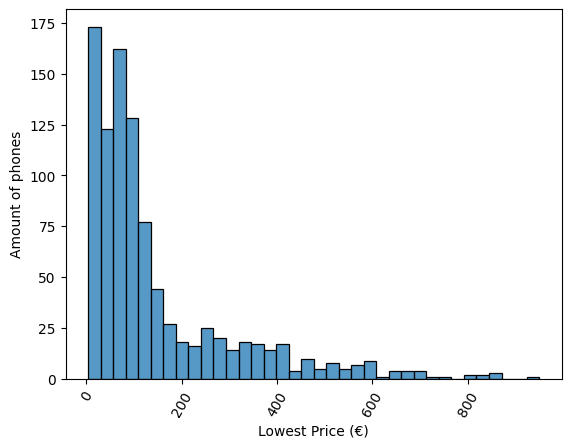

In [152]:
# Price (1)

df['lowest_price'] = pd.to_numeric(
    df['lowest_price'],
    errors='coerce'
)

sns.histplot(x='lowest_price', data=df)

plt.xticks(rotation=60)

plt.xlabel('Lowest Price (€)')
plt.ylabel('Amount of phones')

plt.show()

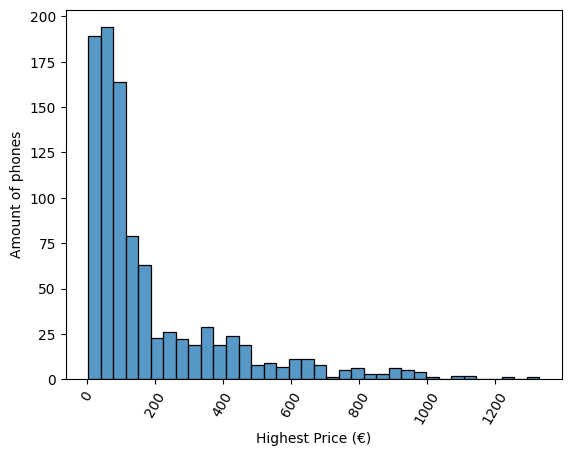

In [153]:
# Price (2)

df['highest_price'] = pd.to_numeric(
    df['highest_price'],
    errors='coerce'
)

sns.histplot(x='highest_price', data=df)

plt.xticks(rotation=60)

plt.xlabel('Highest Price (€)')
plt.ylabel('Amount of phones')

plt.show()

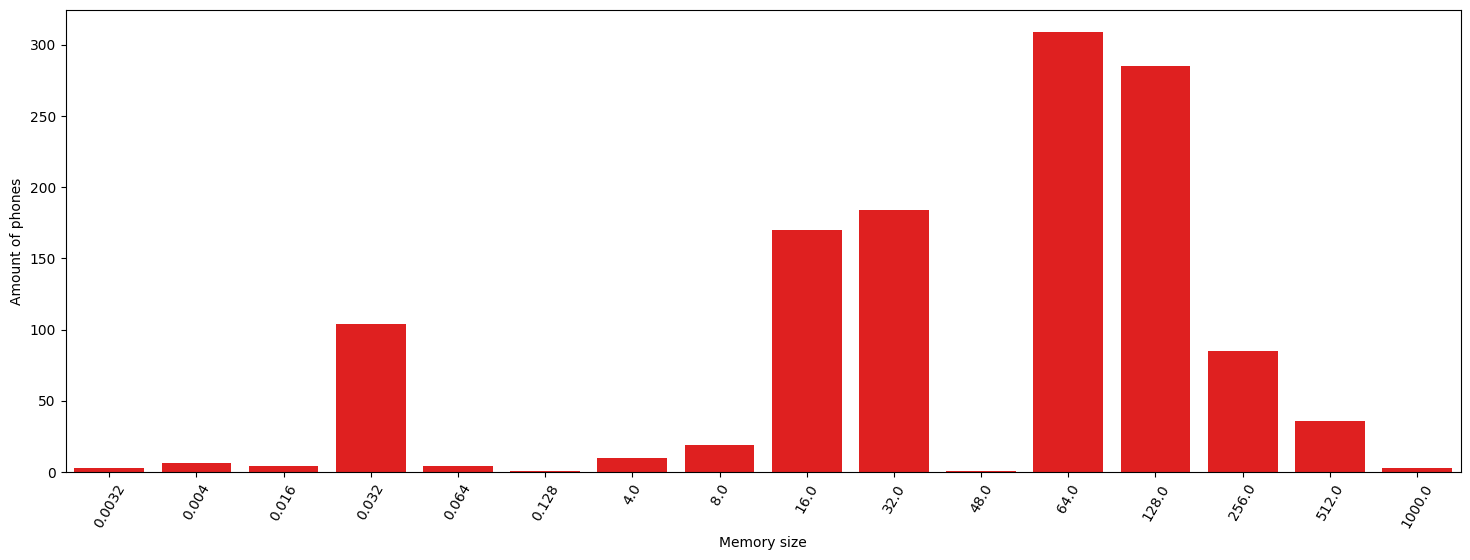

In [154]:
# Phone Specs (1)
plt.figure(figsize=(18, 6))
sns.countplot(x='memory_size', data=df, color = 'red')

plt.xticks(rotation=60)

plt.xlabel('Memory size')
plt.ylabel('Amount of phones')

plt.show()

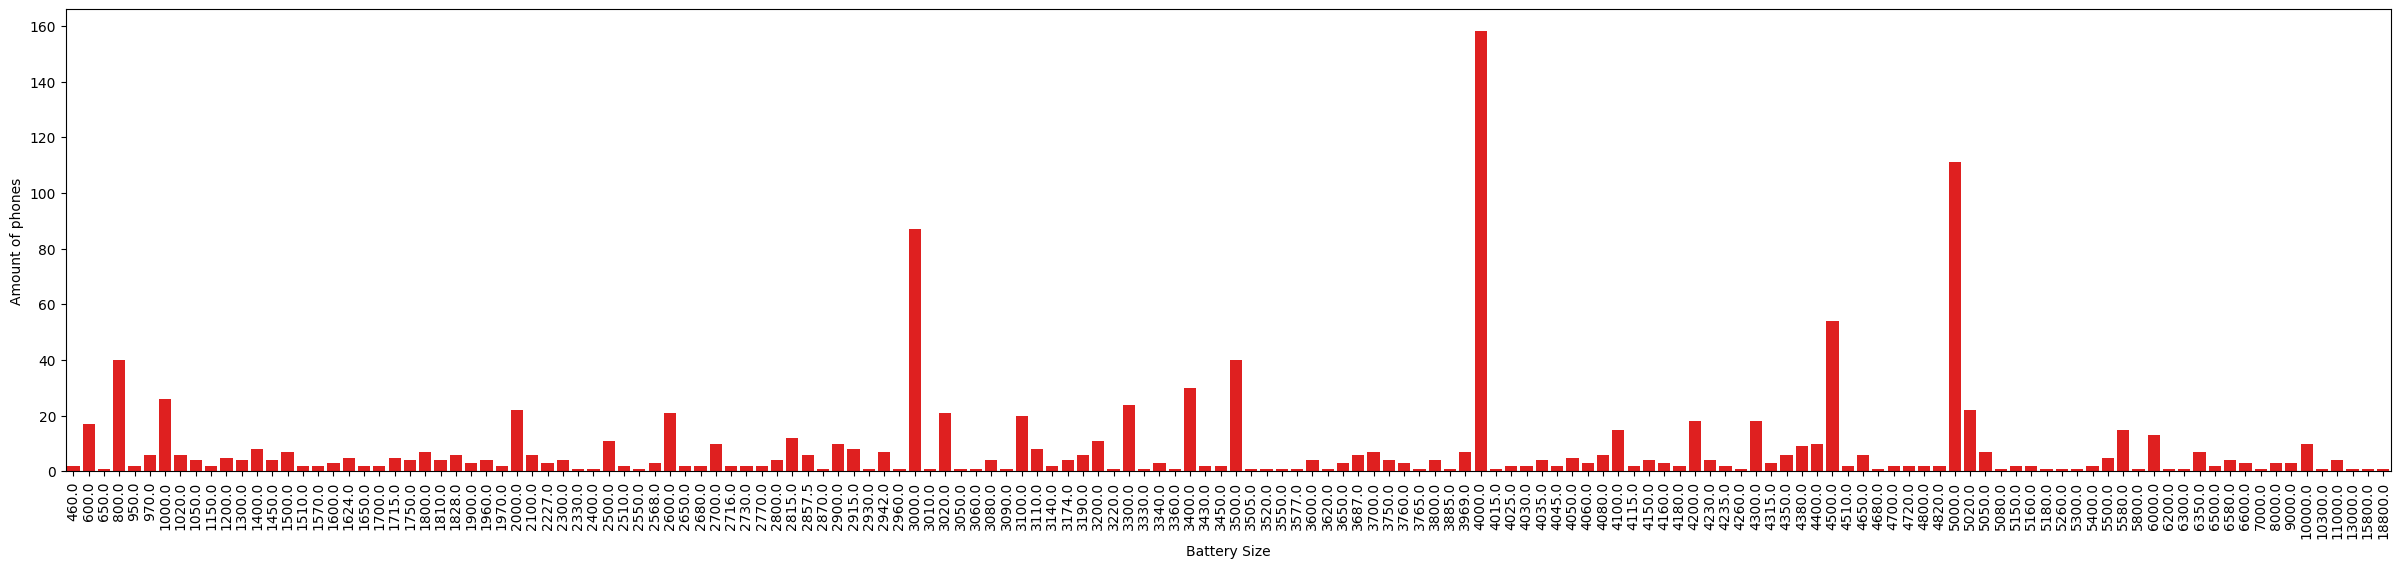

In [155]:
# Phone Specs (2)
plt.figure(figsize=(30, 6))
sns.countplot(x='battery_size', data=df, color = 'red')

plt.xticks(rotation=90)

plt.xlabel('Battery Size')
plt.ylabel('Amount of phones')

plt.show()

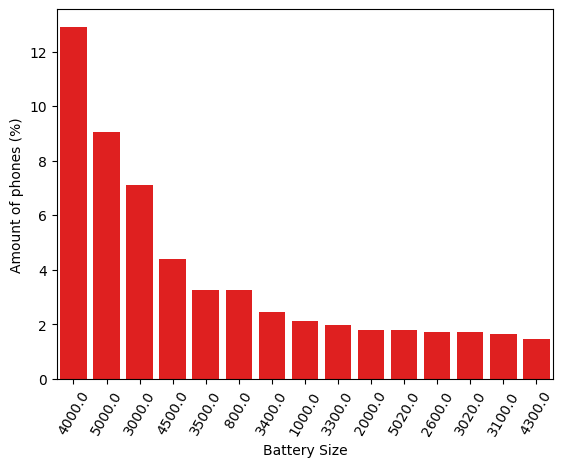

In [156]:
# Phone Specs (3)

# Plotting top N values and filtering them based on percentage

N = 15
order = df['battery_size'].value_counts().head(N).index

sns.countplot(x='battery_size', data=df, order=order, stat = 'percent', color = 'red')
plt.xticks(rotation=60)
plt.xlabel('Battery Size')
plt.ylabel('Amount of phones (%)')
plt.show()

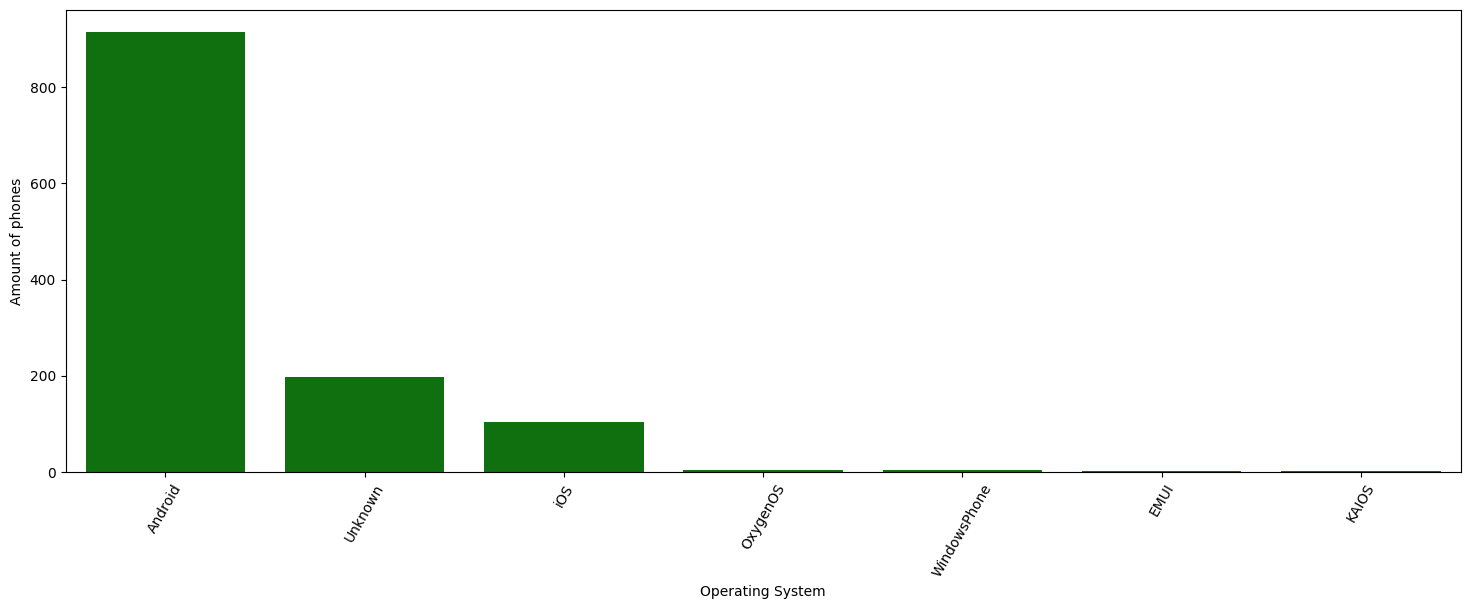

In [157]:
# Popularity (1)
plt.figure(figsize=(18, 6))
sns.countplot(x='os', data=df, color = 'green')

plt.xticks(rotation=60)
plt.xlabel('Operating System')
plt.ylabel('Amount of phones')
plt.show()

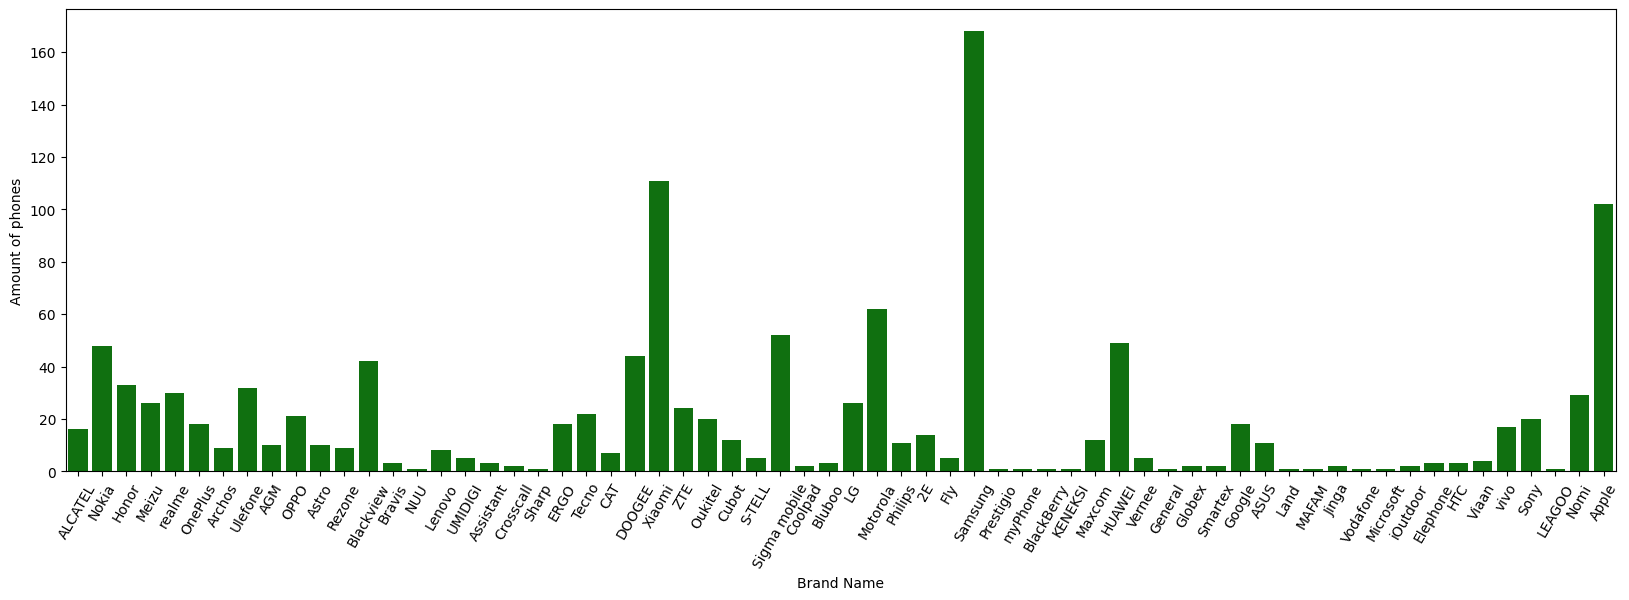

In [158]:
# Popularity (2)

plt.figure(figsize=(20, 6))

sns.countplot(x='brand_name', data=df, color = 'green')
plt.xticks(rotation=60)
plt.xlabel('Brand Name')
plt.ylabel('Amount of phones')
plt.show()

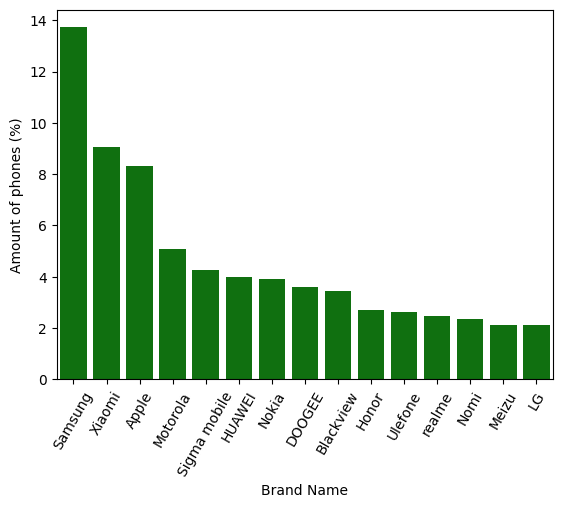

In [159]:
# Popularity (3)

# Plotting top N values and filtering them based on percentage

N = 15
order = df['brand_name'].value_counts().head(N).index

sns.countplot(x='brand_name', data=df, stat = 'percent', color = 'green', order=order)
plt.xticks(rotation=60)
plt.xlabel('Brand Name')
plt.ylabel('Amount of phones (%)')
plt.show()

In [160]:
# Machine Learning
from sklearn.model_selection import train_test_split

test = df.copy()

y = test['best_price']

x = test.drop(['best_price','highest_price','lowest_price'],axis=1)
x = pd.get_dummies(x)

xTrain, xTest, yTrain, yTest = train_test_split(x,y,test_size=0.2)

In [161]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

model_list = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor()
}

train_results = {}
test_results = {}

for name, model in model_list.items():
  model.fit(xTrain,yTrain)

  pTrain = model.predict(xTrain)
  rmseTrain = np.power(mean_squared_error(pTrain,yTrain),0.5)
  maeTrain = mean_absolute_error(pTrain,yTrain)
  mapeTrain = mean_absolute_percentage_error(pTrain,yTrain)
  train_results[name] = (rmseTrain, maeTrain, mapeTrain)
  #print('---------')
  pTest = model.predict(xTest)
  rmseTest = np.power(mean_squared_error(pTest,yTest),0.5)
  maeTest = mean_absolute_error(pTest,yTest)
  mapeTest = mean_absolute_percentage_error(pTest,yTest)
  test_results[name] = (rmseTest, maeTest, mapeTest)


rows = []

for name in model_list.keys():

    train_rmse, train_mae, train_mape = train_results[name]
    test_rmse, test_mae, test_mape = test_results[name]

    rows.append([name, "Train", train_rmse, train_mae, train_mape])
    rows.append([name, "Test", test_rmse, test_mae, test_mape])

table_results = pd.DataFrame(
    rows,
    columns=["Model", "Dataset", "RMSE", "MAE", "MAPE"]
)

print(table_results)

              Model Dataset          RMSE           MAE          MAPE
0  LinearRegression   Train  2.709232e-10  1.915932e-10  5.191800e-12
1  LinearRegression    Test  8.350287e+01  4.749293e+01  9.044569e-01
2      DecisionTree   Train  0.000000e+00  0.000000e+00  0.000000e+00
3      DecisionTree    Test  9.141932e+01  3.904167e+01  2.270686e-01
4      RandomForest   Train  2.526327e+01  1.275532e+01  7.837931e-02
5      RandomForest    Test  7.510814e+01  3.625656e+01  2.004103e-01
6        ExtraTrees   Train  5.913868e-13  3.484018e-13  2.304119e-15
7        ExtraTrees    Test  6.276440e+01  2.860142e+01  1.728955e-01
8  GradientBoosting   Train  4.702439e+01  3.307279e+01  2.774052e-01
9  GradientBoosting    Test  7.118771e+01  4.150883e+01  2.781120e-01
